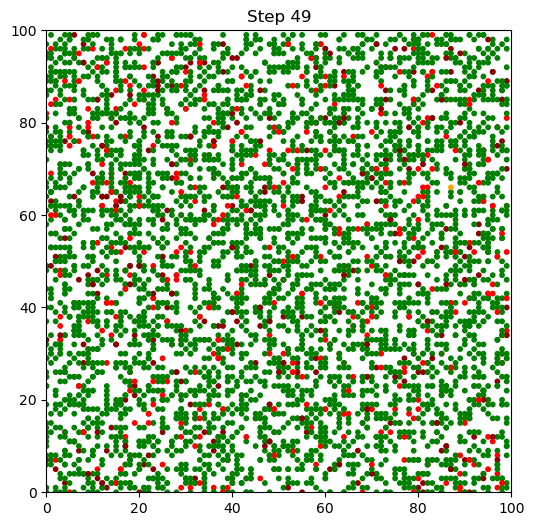

=== Statistics ===
Total infected: 5000
Number of people infected in peak: 3724
Number infected in the last step: 728


In [59]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display


# =========================
# ENVIRONMENT
# =========================

class Environment:
    def __init__(self, width, height):
        self.width = width
        self.height = height
        self.grid = {}

    def place_agent(self, agent, pos):
        if pos not in self.grid:
            self.grid[pos] = []
        self.grid[pos].append(agent)
        agent.pos = pos

    def move_agent(self, agent, new_pos):
        if hasattr(agent, "pos"):
            if agent.pos in self.grid and agent in self.grid[agent.pos]:
                self.grid[agent.pos].remove(agent)

        if new_pos not in self.grid:
            self.grid[new_pos] = []

        self.grid[new_pos].append(agent)
        agent.pos = new_pos

    def get_neighbors(self, agent):
        x, y = agent.pos
        neighbors = []

        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                nx = (x + dx) % self.width
                ny = (y + dy) % self.height

                if (nx, ny) in self.grid:
                    neighbors.extend(self.grid[(nx, ny)])

        return [a for a in neighbors if a.id != agent.id]


# =========================
# AGENT
# =========================

class Person:
    def __init__(self, unique_id, model, state):
        self.id = unique_id
        self.model = model
        self.state = state
        self.pos = None

    def move(self):
        x, y = self.pos

        dx = np.random.choice([-1, 0, 1])
        dy = np.random.choice([-1, 0, 1])

        new_pos = (
            (x + dx) % self.model.env.width,
            (y + dy) % self.model.env.height
        )

        self.model.env.move_agent(self, new_pos)

    def infect(self):
        if self.state != "S":
            return

        neighbors = self.model.get_neighbors(self)

        infected = sum(1 for n in neighbors if n.state in ["Ia", "Is"])

        if infected == 0:
            return

        p = 1 - np.exp(-self.model.beta * infected)

        if np.random.rand() < p:
            self.state = "E"

    def progress(self):
        if self.state == "E":
            if np.random.rand() < self.model.sigma:
                self.state = np.random.choice(["Ia", "Is"], p=[0.6, 0.4])

        elif self.state == "Ia":
            if np.random.rand() < self.model.gamma_a:
                self.state = "R"

        elif self.state == "Is":
            if np.random.rand() < self.model.gamma_s:
                self.state = "R"


# =========================
# MODEL
# =========================

class EpidemicModel:
    def __init__(self, N=800, width=60, height=60):

        self.N = N
        self.env = Environment(width, height)
        self.agents = []

        self.beta = 0.7
        self.sigma = 0.2
        self.gamma_a = 0.05
        self.gamma_s = 0.05

        # --- STATYSTYKI ---
        self.total_infected = 0
        self.peak_infected = 0
        self.history_infected = []

        self.init_agents()

    def init_agents(self):
        for i in range(self.N):

            state = "S"

            if np.random.rand() < 0.03:
                state = "Ia"

            a = Person(i, self, state)

            x = np.random.randint(0, self.env.width)
            y = np.random.randint(0, self.env.height)

            self.env.place_agent(a, (x, y))
            self.agents.append(a)

    def get_neighbors(self, agent):
        return self.env.get_neighbors(agent)

    def step(self):

        for a in self.agents:
            a.move()

        for a in self.agents:
            a.infect()

        for a in self.agents:
            a.progress()

        # --- AKTUALIZACJA STATYSTYK ---
        current_infected = sum(a.state in ["E", "Ia", "Is"] for a in self.agents)
        self.history_infected.append(current_infected)

        if current_infected > self.peak_infected:
            self.peak_infected = current_infected

        self.total_infected = sum(a.state in ["E", "Ia", "Is", "R"] for a in self.agents)


# =========================
# VISUALIZATION 
# =========================

def run_live(model, steps=300):

    color_map = {
        "S": "blue",
        "E": "orange",
        "Ia": "red",
        "Is": "darkred",
        "R": "green"
    }

    for t in range(steps):

        model.step()

        xs = [a.pos[0] for a in model.agents]
        ys = [a.pos[1] for a in model.agents]
        cs = [color_map[a.state] for a in model.agents]

        clear_output(wait=True)
        plt.figure(figsize=(6, 6))
        plt.scatter(xs, ys, s=10, c=cs)
        plt.xlim(0, model.env.width)
        plt.ylim(0, model.env.height)
        plt.title(f"Step {t}")
        plt.show()

    # --- STATYSTYKI KOŃCOWE ---
    print("=== Statistics ===")
    print("Total infected:", model.total_infected)
    print("Number of people infected in peak:", model.peak_infected)
    print("Number infected in the last step:", model.history_infected[-1])


# =========================
# RUN
# =========================

model = EpidemicModel(N=5000, width=100, height=100)
run_live(model, steps=50)


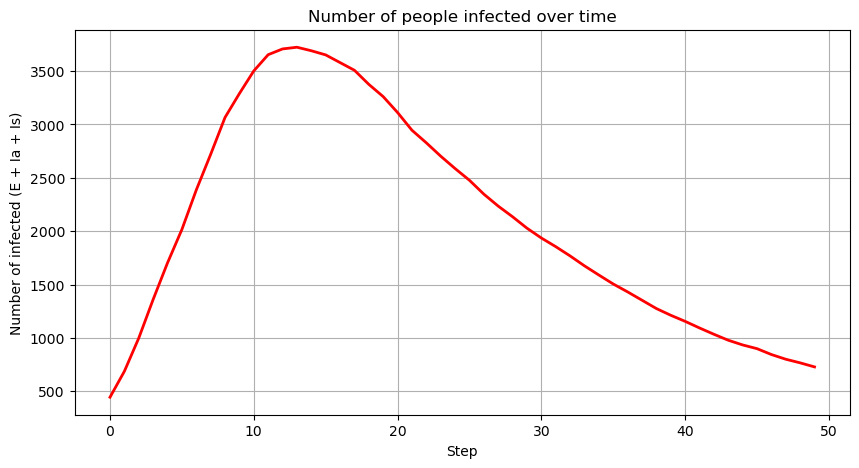

In [60]:
plt.figure(figsize=(10, 5))
plt.plot(model.history_infected, color="red", linewidth=2)
plt.title("Number of people infected over time")
plt.xlabel("Step")
plt.ylabel("Number of infected (E + Ia + Is)")
plt.grid(True)
plt.show()
